In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class LensDataset(Dataset):
    CLASS_NAMES = ['no', 'sphere', 'vort']

    def __init__(self, root_dir, img_size=150, augment=False):
        self.samples  = []
        self.img_size = img_size
        self.augment  = augment

        for label, cls in enumerate(self.CLASS_NAMES):
            cls_path = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_path):
                raise FileNotFoundError(f"Expected class folder: {cls_path}")
            for fname in os.listdir(cls_path):
                if fname.endswith('.npy'):
                    self.samples.append((os.path.join(cls_path, fname), label))

        print(f"Loaded {len(self.samples)} samples from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def _load_image(self, path):
        img = np.load(path).astype(np.float32)
        if img.ndim == 3:
            img = img[0]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        return img

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = self._load_image(path)

        img_t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)
        img_t = F.interpolate(img_t, size=(self.img_size, self.img_size),
                              mode='bilinear', align_corners=False)
        img_t = img_t.squeeze(0)

        if self.augment:
            if random.random() > 0.5:
                img_t = torch.flip(img_t, dims=[-1])
            if random.random() > 0.5:
                img_t = torch.flip(img_t, dims=[-2])
            k = random.randint(0, 3)
            img_t = torch.rot90(img_t, k=k, dims=[-2, -1])

        return img_t, label

In [3]:
from torch.utils.data import random_split, Subset

IMG_SIZE   = 150
BATCH_SIZE = 32

TRAIN_DIR = "/kaggle/input/datasets/anukultiwari/pinn-dataset/dataset_PINN/train"
VAL_DIR   = "/kaggle/input/datasets/anukultiwari/pinn-dataset/dataset_PINN/val"

# 90:10 split of the train folder
full_train = LensDataset(TRAIN_DIR, img_size=IMG_SIZE, augment=False)
n_total    = len(full_train)
n_train    = int(0.9 * n_total)
n_test     = n_total - n_train

train_idx, test_idx = torch.utils.data.random_split(
    range(n_total), [n_train, n_test],
    generator=torch.Generator().manual_seed(42)
)

# Augment only the training portion
train_dataset = LensDataset(TRAIN_DIR, img_size=IMG_SIZE, augment=True)
train_dataset = Subset(train_dataset, train_idx.indices)

test_dataset  = Subset(full_train, test_idx.indices)

# Provided val folder (for final reporting)
val_dataset   = LensDataset(VAL_DIR, img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)} | Internal test (10%): {len(test_dataset)} | Val folder: {len(val_dataset)}")

Loaded 30000 samples from /kaggle/input/datasets/anukultiwari/pinn-dataset/dataset_PINN/train
Loaded 30000 samples from /kaggle/input/datasets/anukultiwari/pinn-dataset/dataset_PINN/train
Loaded 7500 samples from /kaggle/input/datasets/anukultiwari/pinn-dataset/dataset_PINN/val
Train: 27000 | Internal test (10%): 3000 | Val folder: 7500


In [4]:
class PolarTransform(nn.Module):
    def __init__(self, out_size=150):
        super().__init__()
        self.out_size = out_size

        self._build_grid(out_size)

    def _build_grid(self, S):

        r_vals   = torch.linspace(0, 1,    S)
        phi_vals = torch.linspace(-torch.pi, torch.pi, S)

        r_grid, phi_grid = torch.meshgrid(r_vals, phi_vals, indexing='ij')

        x = r_grid * torch.cos(phi_grid)
        y = r_grid * torch.sin(phi_grid)

        grid = torch.stack([x, y], dim=-1).unsqueeze(0)
        self.register_buffer('grid', grid)

    def forward(self, x):
        B = x.size(0)
        grid = self.grid.expand(B, -1, -1, -1)
        polar = F.grid_sample(x, grid,
                              mode='bilinear',
                              padding_mode='zeros',
                              align_corners=True)
        return polar

In [5]:
class LensWarp(nn.Module):
    def forward(self, source, alpha):
        B, C, H, W = source.shape
        ys = torch.linspace(-1, 1, H, device=source.device)
        xs = torch.linspace(-1, 1, W, device=source.device)
        grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
        identity = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0).expand(B, -1, -1, -1)
        alpha_perm  = alpha.permute(0, 2, 3, 1)
        sample_grid = (identity - alpha_perm).clamp(-1, 1)
        return F.grid_sample(source, sample_grid,
                             mode='bilinear', padding_mode='border',
                             align_corners=True)

class SISPrior(nn.Module):
    def __init__(self, in_channels, img_size=150):
        super().__init__()
        self.theta_E_head = nn.Sequential(
            nn.Linear(in_channels, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1),
            nn.Softplus()
        )

        xs = torch.linspace(-1, 1, img_size)
        ys = torch.linspace(-1, 1, img_size)
        grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
        r = torch.sqrt(grid_x**2 + grid_y**2 + 1e-6)
        self.register_buffer('r', r.unsqueeze(0).unsqueeze(0))

    def forward(self, feat):
        if feat.dim() == 4:
            feat = feat.mean(dim=[2, 3])

        theta_E  = self.theta_E_head(feat)
        psi_sis  = theta_E.unsqueeze(-1).unsqueeze(-1) * self.r
        return psi_sis, theta_E.squeeze(1)
        
class PotentialHead(nn.Module):
    SEED = 4

    def __init__(self, in_channels, img_size=150):
        super().__init__()
        self.img_size  = img_size
        self.sis_prior = SISPrior(in_channels, img_size)
        self.channel_reduce = nn.Conv2d(32, 1, kernel_size=1)
        nn.init.normal_(self.channel_reduce.weight, std=0.01)
        nn.init.zeros_(self.channel_reduce.bias)
        xs = torch.linspace(-1, 1, img_size)
        ys = torch.linspace(-1, 1, img_size)
        grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
        sigma = 0.9
        gauss = torch.exp(-(grid_x**2 + grid_y**2) / (2 * sigma**2))
        self.register_buffer('gauss_window', gauss.unsqueeze(0).unsqueeze(0))
        self.fc = nn.Linear(in_channels, 256 * self.SEED * self.SEED)
        self.decode = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64,  32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
        )
        Kx = torch.tensor([[-1., 0., 1.],
                            [-2., 0., 2.],
                            [-1., 0., 1.]]).view(1, 1, 3, 3) / 8.0
        self.register_buffer('Kx', Kx)
        self.register_buffer('Ky', Kx.transpose(-2, -1).contiguous())
    def forward(self, feat):
        B = feat.size(0)
    
        psi_sis, theta_E = self.sis_prior(feat)
    
        x         = self.fc(feat).view(B, 256, self.SEED, self.SEED)
        psi_resid = self.decode(x)
        psi_resid = F.interpolate(psi_resid, size=(self.img_size, self.img_size),
                                  mode='bilinear', align_corners=False)
        psi_resid_1ch = self.channel_reduce(psi_resid)
        psi_resid_1ch = psi_resid_1ch * self.gauss_window
        psi_total = psi_sis + psi_resid_1ch
    
        dpsi_dx = F.conv2d(psi_total, self.Kx, padding=1)
        dpsi_dy = F.conv2d(psi_total, self.Ky, padding=1)
        alpha   = torch.tanh(torch.cat([dpsi_dx, dpsi_dy], dim=1))
    
        return psi_total, psi_resid_1ch, alpha, theta_E

class SourceDecoder(nn.Module):
    SEED = 4

    def __init__(self, in_channels, img_size=150):
        super().__init__()
        self.img_size = img_size
        self.fc = nn.Linear(in_channels, 128 * self.SEED * self.SEED)
        self.decode = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64,  4, stride=2, padding=1),
            nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64,  32,  4, stride=2, padding=1),
            nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32,  16,  4, stride=2, padding=1),
            nn.BatchNorm2d(16),  nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, feat):
        B = feat.size(0)
        x   = self.fc(feat).view(B, 128, self.SEED, self.SEED)
        src = self.decode(x)
        src = F.interpolate(src, size=(self.img_size, self.img_size),
                            mode='bilinear', align_corners=False)

        blur_k = torch.ones(1, 1, 3, 3, device=src.device) / 9.0
        src = F.conv2d(src, blur_k, padding=1).clamp(0, 1)
        return src


In [6]:
class ResidualEncoder(nn.Module):
    def __init__(self, residual_dim=128):
        super().__init__()
        self.net = nn.Sequential(

            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(inplace=True),

            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, residual_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, residual_map):
        return self.net(residual_map)

In [7]:
class PolarEncoder(nn.Module):
    def __init__(self, polar_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, polar_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, polar_img):
        return self.net(polar_img)

In [8]:
class PINNLensNet(nn.Module):
    RESIDUAL_DIM = 128
    POLAR_DIM    = 128

    def __init__(self, num_classes=3, img_size=150):
        super().__init__()
        self.img_size = img_size

        from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
        backbone = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        orig_conv = backbone.features[0][0]
        new_conv  = nn.Conv2d(1, orig_conv.out_channels,
                              kernel_size=orig_conv.kernel_size,
                              stride=orig_conv.stride,
                              padding=orig_conv.padding, bias=False)
        with torch.no_grad():
            new_conv.weight.data = orig_conv.weight.data.mean(dim=1, keepdim=True)
        backbone.features[0][0] = new_conv
        self.feat_dim = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
        self.encoder = backbone

        self.potential_head  = PotentialHead(self.feat_dim, img_size)
        self.source_decoder  = SourceDecoder(self.feat_dim, img_size)
        self.lens_warp       = LensWarp()

        self.residual_encoder = ResidualEncoder(self.RESIDUAL_DIM)

        self.polar_transform = PolarTransform(out_size=img_size)
        self.polar_encoder   = PolarEncoder(self.POLAR_DIM)

        fused_dim = self.feat_dim + self.RESIDUAL_DIM + self.POLAR_DIM
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(fused_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        feat = self.encoder(x)

        psi, psi_resid, alpha, theta_E = self.potential_head(feat)
        i_src   = self.source_decoder(feat)
        i_recon = self.lens_warp(i_src, alpha)

        residual = torch.abs(x - i_recon)
        res_feat = self.residual_encoder(residual)

        polar_img  = self.polar_transform(x)
        polar_feat = self.polar_encoder(polar_img)

        fused  = torch.cat([feat, res_feat, polar_feat], dim=1)
        logits = self.classifier(fused)

        return logits, psi, psi_resid, alpha, theta_E, i_recon, i_src, residual


In [9]:
def compute_sobel_derivatives(field):
    device = field.device
    Kx = torch.tensor([[-1., 0., 1.],
                        [-2., 0., 2.],
                        [-1., 0., 1.]], device=device).view(1, 1, 3, 3) / 8.0
    Ky = Kx.transpose(-2, -1).contiguous()
    return F.conv2d(field, Kx, padding=1), F.conv2d(field, Ky, padding=1)

def physics_loss(psi_resid, alpha, i_input, i_recon,resid_reg_loss,
                 lambda_poisson=0.05,
                 lambda_curl=0.01,
                 lambda_recon=1.0,
                 epoch=1, warmup_epochs=5):
    phys_weight = min(1.0, 0.1 + 0.9 * (epoch - 1) / max(warmup_epochs - 1, 1))

    dpsi_dx, dpsi_dy  = compute_sobel_derivatives(psi_resid)
    d2psi_dx2, _      = compute_sobel_derivatives(dpsi_dx)
    _, d2psi_dy2      = compute_sobel_derivatives(dpsi_dy)
    kappa_sub         = (d2psi_dx2 + d2psi_dy2) / 2.0
    l_poisson         = (kappa_sub ** 2).mean()

    dax_dx, dax_dy = compute_sobel_derivatives(alpha[:, 0:1])
    day_dx, day_dy = compute_sobel_derivatives(alpha[:, 1:2])
    l_curl         = ((day_dx - dax_dy) ** 2).mean()

    l_recon = F.mse_loss(i_recon, i_input)

    total = (phys_weight * lambda_poisson * l_poisson
           + phys_weight * lambda_curl    * l_curl
           +               lambda_recon   * l_recon
           + resid_reg_loss  )

    return total, {
        'poisson':     l_poisson.item(),
        'curl':        l_curl.item(),
        'recon':       l_recon.item(),
        'phys_weight': phys_weight,
    }


In [10]:
model     = PINNLensNet(num_classes=3, img_size=IMG_SIZE).to(device)
criterion = nn.CrossEntropyLoss()

encoder_params     = list(model.encoder.parameters())
non_encoder_params = (list(model.potential_head.parameters())
                    + list(model.source_decoder.parameters())
                    + list(model.residual_encoder.parameters())
                    + list(model.polar_encoder.parameters())
                    + list(model.classifier.parameters()))

optimizer = torch.optim.Adam([
    {'params': encoder_params,     'lr': 5e-5},
    {'params': non_encoder_params, 'lr': 1e-4}
], weight_decay=1e-4)

NUM_EPOCHS    = 50
WARMUP_EPOCHS = 5
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters : {total_params:,}")
print(f"  Encoder        : {sum(p.numel() for p in model.encoder.parameters()):,}")
print(f"  Potential head : {sum(p.numel() for p in model.potential_head.parameters()):,}")
print(f"  Source decoder : {sum(p.numel() for p in model.source_decoder.parameters()):,}")
print(f"  Residual branch: {sum(p.numel() for p in model.residual_encoder.parameters()):,}")
print(f"  Polar branch   : {sum(p.numel() for p in model.polar_encoder.parameters()):,}")
print(f"  Classifier     : {sum(p.numel() for p in model.classifier.parameters()):,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 204MB/s]


Total parameters : 22,711,582
  Encoder        : 10,695,512
  Potential head : 7,372,354
  Source decoder : 3,582,689
  Residual branch: 31,840
  Polar branch   : 109,632
  Classifier     : 919,555


In [11]:
def train_epoch(model, loader, epoch):
    model.train()
    totals = {'total': 0., 'cls': 0., 'phys': 0.,
              'poisson': 0., 'curl': 0., 'recon': 0.}
    n = 0

    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()

        logits, psi, psi_resid, alpha, theta_E, i_recon, i_src, residual = model(imgs)
        resid_reg_loss = 1e-4 * (psi_resid ** 2).mean()
        cls_loss = criterion(logits, labels)
        phys, components = physics_loss(psi_resid, alpha, imgs, i_recon,resid_reg_loss,
                                        epoch=epoch,
                                        warmup_epochs=WARMUP_EPOCHS)

        loss = cls_loss + phys
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        B = imgs.size(0)
        totals['total']   += loss.item() * B
        totals['cls']     += cls_loss.item() * B
        totals['phys']    += phys.item() * B
        for k in ('poisson', 'curl', 'recon'):
            totals[k] += components[k] * B
        n += B

    return {k: v / n for k, v in totals.items()}

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels, all_probs = [], []

    for imgs, labels in tqdm(loader, desc='Eval ', leave=False):
        imgs = imgs.to(device)
        logits, *_ = model(imgs)
        probs = F.softmax(logits, dim=1)
        all_labels.append(labels.numpy())
        all_probs.append(probs.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_probs  = np.concatenate(all_probs)
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    return auc, all_labels, all_probs


In [12]:
history = {'train_loss': [], 'val_auc': [], 'cls_loss': [],
           'phys_loss': [], 'recon_loss': [], 'curl_loss': [], 'poisson_loss': []}
best_auc, best_epoch = 0., 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_stats = train_epoch(model, train_loader, epoch)
    val_auc, _, _ = evaluate(model, val_loader)
    scheduler.step()

    history['train_loss'].append(train_stats['total'])
    history['val_auc'].append(val_auc)
    history['cls_loss'].append(train_stats['cls'])
    history['phys_loss'].append(train_stats['phys'])
    history['recon_loss'].append(train_stats['recon'])
    history['curl_loss'].append(train_stats['curl'])
    history['poisson_loss'].append(train_stats['poisson'])

    if val_auc > best_auc:
        best_auc, best_epoch = val_auc, epoch
        torch.save(model.state_dict(), 'best_pinn_model.pt')
        marker = '  < best'
    else:
        marker = ''

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Loss={train_stats['total']:.4f} "
          f"(cls={train_stats['cls']:.4f} "
          f"recon={train_stats['recon']:.4f} "
          f"curl={train_stats['curl']:.2e} "
          f"poisson={train_stats['poisson']:.2e}) | "
          f"AUC={val_auc:.4f}{marker}")

print(f"\nBest model: Epoch {best_epoch}, AUC={best_auc:.4f}")


Epoch 01/50 | Loss=1.1166 (cls=1.0724 recon=0.0442 curl=2.92e-06 poisson=3.23e-04) | AUC=0.6630  < best


Epoch 02/50 | Loss=0.9667 (cls=0.9538 recon=0.0128 curl=6.25e-06 poisson=4.89e-04) | AUC=0.7749  < best


Epoch 03/50 | Loss=0.8284 (cls=0.8202 recon=0.0081 curl=8.13e-06 poisson=5.20e-04) | AUC=0.8507  < best


Epoch 04/50 | Loss=0.7019 (cls=0.6963 recon=0.0055 curl=9.36e-06 poisson=5.81e-04) | AUC=0.8932  < best


Epoch 05/50 | Loss=0.6138 (cls=0.6096 recon=0.0042 curl=1.09e-05 poisson=6.67e-04) | AUC=0.9148  < best


...

Epoch 46/50 | Loss=0.1425 (cls=0.1412 recon=0.0012 curl=5.90e-07 poisson=1.59e-04) | AUC=0.9893  < best


Epoch 47/50 | Loss=0.1400 (cls=0.1388 recon=0.0012 curl=5.90e-07 poisson=1.60e-04) | AUC=0.9892


Epoch 48/50 | Loss=0.1407 (cls=0.1395 recon=0.0012 curl=5.89e-07 poisson=1.59e-04) | AUC=0.9892


Epoch 49/50 | Loss=0.1406 (cls=0.1394 recon=0.0012 curl=5.88e-07 poisson=1.59e-04) | AUC=0.9893


Epoch 50/50 | Loss=0.1431 (cls=0.1419 recon=0.0012 curl=5.88e-07 poisson=1.59e-04) | AUC=0.9893

Best model: Epoch 46, AUC=0.9893


In [13]:
model.load_state_dict(torch.load('best_pinn_model.pt'))

# Metrics on internal 10% holdout
test_auc, test_labels, test_probs = evaluate(model, test_loader)
print(f"Internal Test AUC (10% holdout): {test_auc:.4f}")

# Metrics on provided val folder
val_auc, val_labels, val_probs = evaluate(model, val_loader)
print(f"Provided Val Folder AUC:         {val_auc:.4f}")

Internal Test AUC (10% holdout): 0.9897


Provided Val Folder AUC:         0.9893


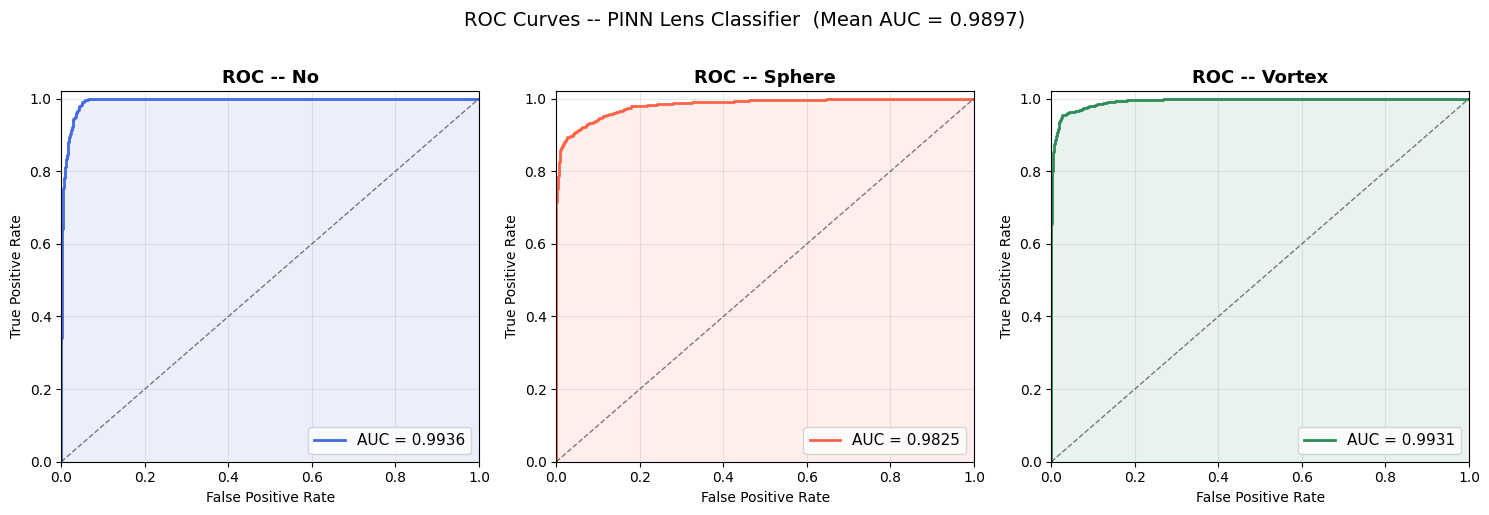

Saved: roc_curves_test.png


In [18]:
CLASS_LABELS = ['No', 'Sphere', 'Vortex']
y_bin = label_binarize(test_labels, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['royalblue', 'tomato', 'seagreen']

for i, (ax, color, name) in enumerate(zip(axes, colors, CLASS_LABELS)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], test_probs[:, i])
    auc_i = roc_auc_score(y_bin[:, i], test_probs[:, i])

    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc_i:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.set_title(f'ROC -- {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=11)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.grid(alpha=0.3)

plt.suptitle(f'ROC Curves -- PINN Lens Classifier  (Mean AUC = {test_auc:.4f})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curves_test.png")

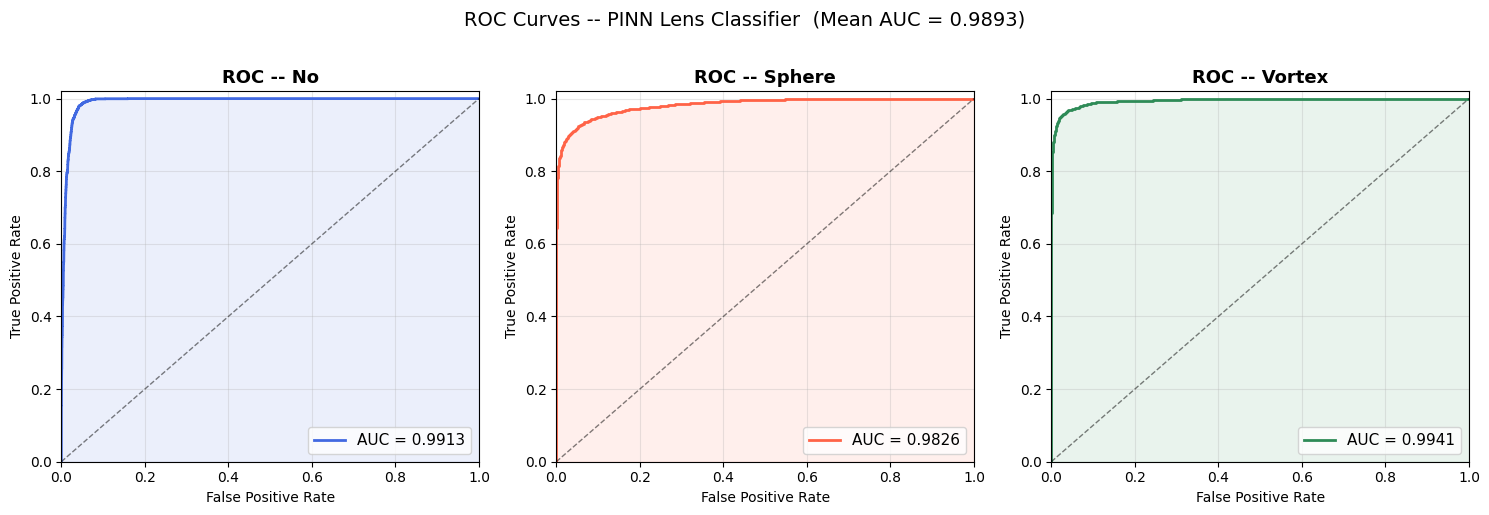

Saved: roc_curves_val.png


In [20]:
CLASS_LABELS = ['No', 'Sphere', 'Vortex']
y_bin = label_binarize(val_labels, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['royalblue', 'tomato', 'seagreen']

for i, (ax, color, name) in enumerate(zip(axes, colors, CLASS_LABELS)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], val_probs[:, i])
    auc_i = roc_auc_score(y_bin[:, i], val_probs[:, i])

    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc_i:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.set_title(f'ROC -- {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=11)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.grid(alpha=0.3)

plt.suptitle(f'ROC Curves -- PINN Lens Classifier  (Mean AUC = {val_auc:.4f})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curves_val.png")

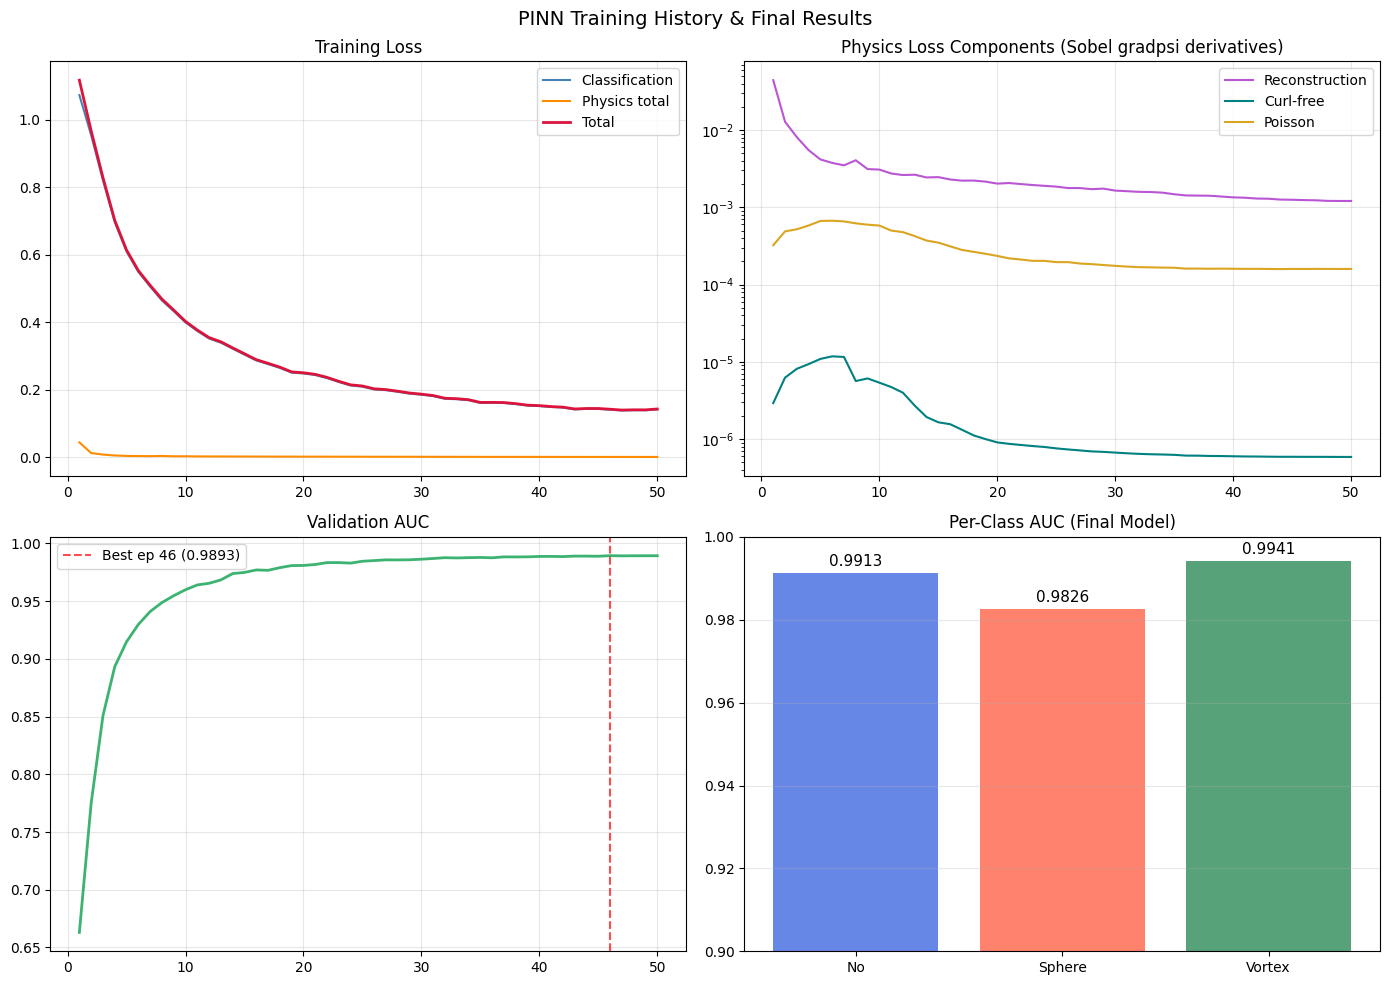

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ep = range(1, NUM_EPOCHS + 1)

axes[0,0].plot(ep, history['cls_loss'],   label='Classification', color='steelblue')
axes[0,0].plot(ep, history['phys_loss'],  label='Physics total',  color='darkorange')
axes[0,0].plot(ep, history['train_loss'], label='Total',          color='crimson', lw=2)
axes[0,0].set_title('Training Loss'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ep, history['recon_loss'],   label='Reconstruction', color='mediumorchid')
axes[0,1].plot(ep, history['curl_loss'],    label='Curl-free',      color='teal')
axes[0,1].plot(ep, history['poisson_loss'], label='Poisson',        color='goldenrod')
axes[0,1].set_title('Physics Loss Components (Sobel gradpsi derivatives)')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)
axes[0,1].set_yscale('log')

axes[1,0].plot(ep, history['val_auc'], color='mediumseagreen', lw=2)
axes[1,0].axvline(best_epoch, color='red', ls='--', alpha=0.7,
                  label=f'Best ep {best_epoch} ({best_auc:.4f})')
axes[1,0].set_title('Validation AUC'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

for i, (name, color) in enumerate(zip(CLASS_LABELS, colors)):
    auc_i = roc_auc_score(y_bin[:, i], val_probs[:, i])
    axes[1,1].bar(name, auc_i, color=color, alpha=0.8)
axes[1,1].set_ylim([0.9, 1.0])
axes[1,1].set_title('Per-Class AUC (Final Model)')
axes[1,1].grid(axis='y', alpha=0.3)
for bar in axes[1,1].patches:
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.001,
                   f'{bar.get_height():.4f}',
                   ha='center', va='bottom', fontsize=11)

plt.suptitle('PINN Training History & Final Results', fontsize=14)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

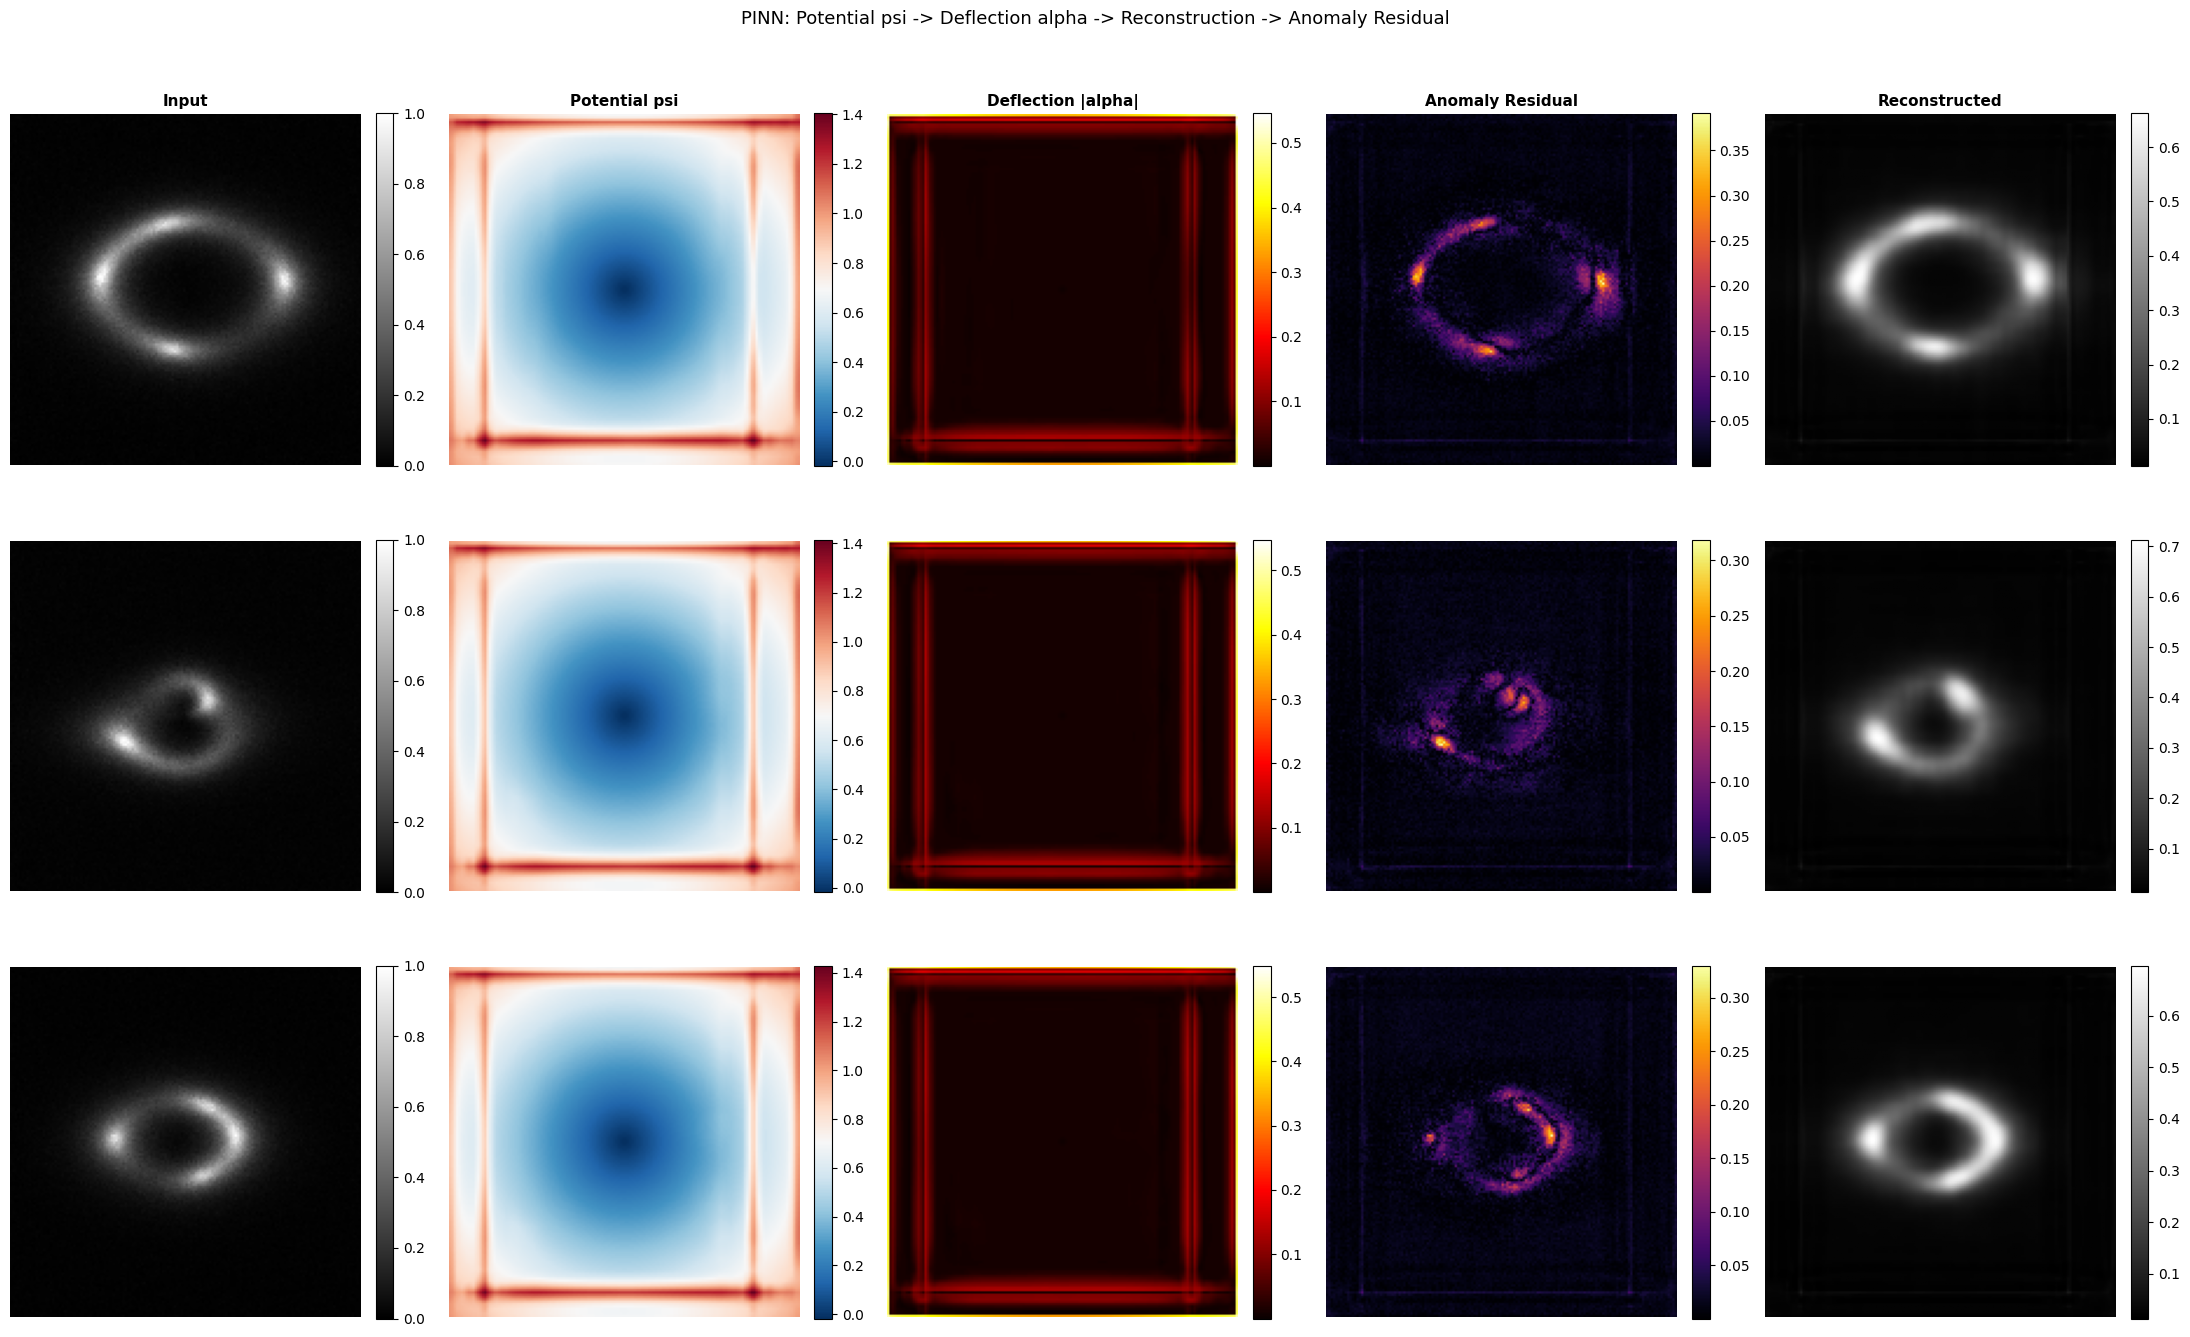

In [23]:
@torch.no_grad()
def visualize_all(model, dataset, n_samples=3):
    model.eval()
    indices = random.sample(range(len(dataset)), n_samples)
    class_labels = ['No Substructure', 'Subhalo', 'Vortex']

    col_titles = ['Input', 'Potential psi', 'Deflection |alpha|',
                  'Anomaly Residual', 'Reconstructed']
    cmaps      = ['gray', 'RdBu_r', 'hot', 'inferno', 'gray']

    fig, axes = plt.subplots(n_samples, 5, figsize=(22, 4.5 * n_samples))
    if n_samples == 1:
        axes = axes[np.newaxis, :]

    for ax, t in zip(axes[0], col_titles):
        ax.set_title(t, fontsize=11, fontweight='bold')

    for row, idx in enumerate(indices):
        img, label = dataset[idx]
        x = img.unsqueeze(0).to(device)

        logits, psi, psi_resid, alpha, theta_E, i_recon, _, residual = model(x)
        pred = logits.argmax(dim=1).item()

        alpha_np    = alpha[0].cpu().numpy()
        magnitude   = np.sqrt(alpha_np[0]**2 + alpha_np[1]**2)
        psi_np      = psi[0, 0].cpu().numpy()
        residual_np = residual[0, 0].cpu().numpy()
        recon_np    = i_recon[0, 0].cpu().numpy()
        img_np      = img[0].numpy()

        imgs_to_show = [img_np, psi_np, magnitude, residual_np, recon_np]

        gt_correct = 'v' if pred == label else 'x'
        axes[row, 0].set_ylabel(
            f'{gt_correct} GT: {class_labels[label]}\n   Pred: {class_labels[pred]}',
            fontsize=9)

        for col, (arr, cmap) in enumerate(zip(imgs_to_show, cmaps)):
            im = axes[row, col].imshow(arr, cmap=cmap)
            plt.colorbar(im, ax=axes[row, col], fraction=0.046, pad=0.04)
            axes[row, col].axis('off')

    plt.suptitle('PINN: Potential psi -> Deflection alpha -> Reconstruction -> Anomaly Residual',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('pinn_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_all(model, val_dataset, n_samples=3)


In [24]:
print("=" * 64)
print("  PINN Gravitational Lensing Classifier -- Final Summary")
print("=" * 64)
print(f"  Backbone            : EfficientNet-B3 (pretrained, 1-ch)")
print(f"  Input size          : {IMG_SIZE}x{IMG_SIZE}")
print()
print("  Architecture -- Physics Embedded by Design:")
print("    SIS prior:   psi_SIS = theta_E * r   (learnable Einstein radius)")
print("    Residual:    psi_total = psi_SIS + psi_resid  (CNN predicts deviations)")
print("    Deflection:  alpha = gradpsi_total       (curl-free BY CONSTRUCTION)")
print("    Warp:        beta = theta - alpha(theta)       (lensing equation as forward pass)")
print("    Poisson:     Deltapsi_resid = 2kappa_sub  (subhalo convergence constraint)")
print()
print("  Novel Contributions:")
print("  A. Anomaly Residual Branch  |I - I_recon| -> substructure signal")
print("  B. Potential-Derived alpha      psi_SIS + psi_resid -> alpha = gradpsi structurally")
print("  C. Polar Coordinate Branch  exploits circular lensing symmetry")
print()
print("  Physics Losses (curriculum-ramped over 5 warmup epochs):")
print("    ||Deltapsi_resid||^2  (Poisson / kappa_sub)  +  ||gradxalpha||^2  +  MSE recon")
print(f"  Best epoch          : {best_epoch}")
print(f"  Best Val AUC (OvR)  : {best_auc:.4f}")
print("=" * 64)


  PINN Gravitational Lensing Classifier -- Final Summary
  Backbone            : EfficientNet-B3 (pretrained, 1-ch)
  Input size          : 150x150

  Architecture -- Physics Embedded by Design:
    SIS prior:   psi_SIS = theta_E * r   (learnable Einstein radius)
    Residual:    psi_total = psi_SIS + psi_resid  (CNN predicts deviations)
    Deflection:  alpha = gradpsi_total       (curl-free BY CONSTRUCTION)
    Warp:        beta = theta - alpha(theta)       (lensing equation as forward pass)
    Poisson:     Deltapsi_resid = 2kappa_sub  (subhalo convergence constraint)

  Novel Contributions:
  A. Anomaly Residual Branch  |I - I_recon| -> substructure signal
  B. Potential-Derived alpha      psi_SIS + psi_resid -> alpha = gradpsi structurally
  C. Polar Coordinate Branch  exploits circular lensing symmetry

  Physics Losses (curriculum-ramped over 5 warmup epochs):
    ||Deltapsi_resid||^2  (Poisson / kappa_sub)  +  ||gradxalpha||^2  +  MSE recon
  Best epoch          : 46
  Best Val